# Simple Linear Regression

## Problem Statement

We want to predict Salary based on Years of Experience using Simple Linear Regression.

Type of ML problem: Regression (continuous output)

### Step 1: Import Required Libraries

We import libraries for data handling, visualization, and machine learning.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as n

### Step 2: Load the Dataset

In [7]:
df=pd.read_csv(r"C:\Users\saptu\Downloads\Salary_dataset.csv")
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


### Step 3: Basic Exploratory Data Analysis (EDA)

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [9]:
df.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


Visualizing the Relationship Between Experience and Salary: Linear Regression assumes a linear relationship between input and output.

Visualizing the Relationship Between Experience and Salary

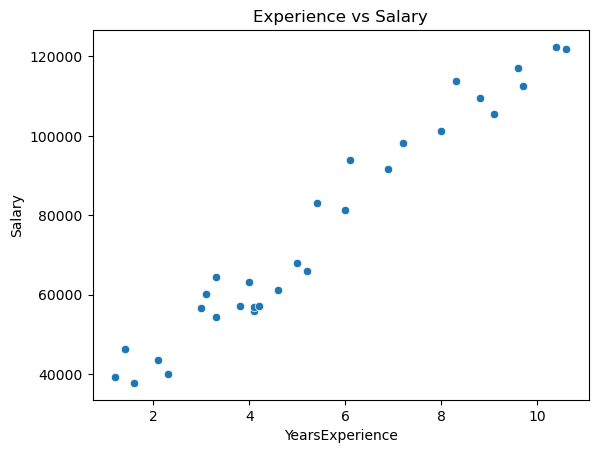

In [10]:
sns.scatterplot(x='YearsExperience', y='Salary', data=df, markers = 'o')
plt.title("Experience vs Salary")
plt.show()

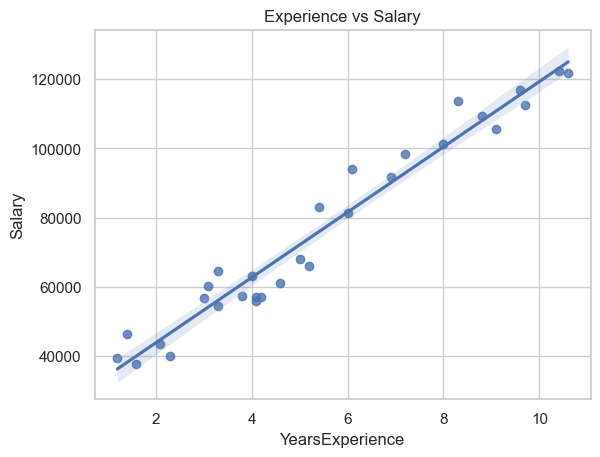

In [15]:
sns.set(style="whitegrid")
sns.regplot(x='YearsExperience', y='Salary', data=df)
plt.title("Experience vs Salary")
plt.show()

### Step 4: Feature and Target Selection

Feature (X): Years of Experience
Target (y): Salary

In [19]:
X = df[['YearsExperience']]
y = df['Salary']

### Step 5: Train–Test Split

We split the dataset to evaluate how well the model performs on unseen data.

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state=42
)

### Step 6: Model Training – Linear Regression

Here, the model learns the relationship:
    salary = m x Experience + c

In [23]:
from sklearn.linear_model import LinearRegression 

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Model Parameters
>Coefficient (m): Rate of salary increase per year of experience
>Intercept (c): Salary when experience is zero

In [25]:
model.coef_,model.intercept_

(array([9423.81532303]), 24380.20147947369)

### Step 7: Predictions

We use the trained model to predict salaries for test data.

In [26]:
y_pred = model.predict(X_test)

In [27]:
comparison = pd.DataFrame({
    "Actual Salary": y_test.values,
    "Predicted Salary": y_pred
})

comparison

,Actual Salary,Predicted Salary
0,112636.0,115791.210113
1,67939.0,71499.278095
2,113813.0,102597.868661
3,83089.0,75268.804224
4,64446.0,55478.792045
5,57190.0,60190.699707


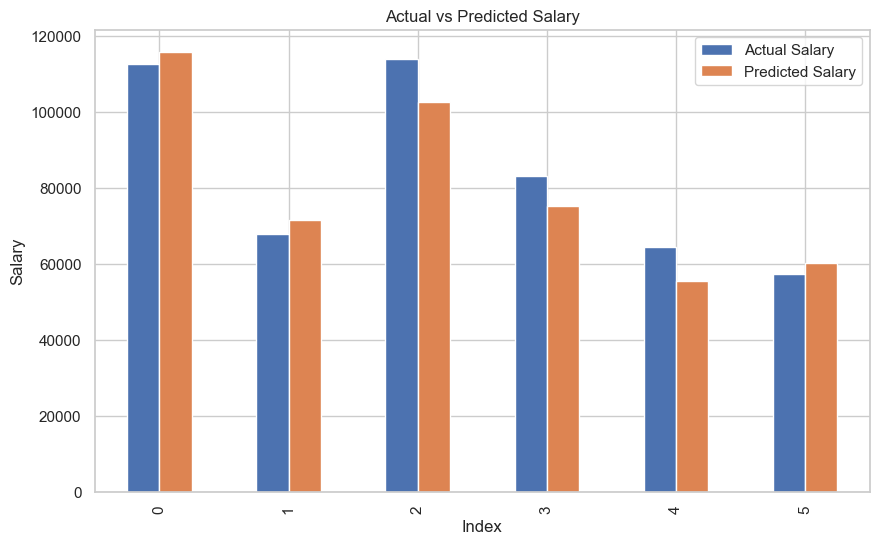

In [28]:
comparison.plot(kind='bar',figsize=(10,6))
plt.title("Actual vs Predicted Salary")
plt.xlabel("Index")
plt.ylabel("Salary")
plt.legend()
plt.show()

### Step 8: Model Evaluation (Regression Metrics)

Regression models are evaluated using error-based metrics.

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

mae, mse, rmse, r2

(6286.453830757745, 49830096.855908334, 7059.043621901506, 0.9024461774180498)

Metric Interpretation

>MAE: Average absolute prediction error 
>RMSE: Penalizes large errors 
>R²_Score: Proportion of variance explained by the model

### Step 9: Visualizing Regression Line

The distance of points from the line represents prediction error. 

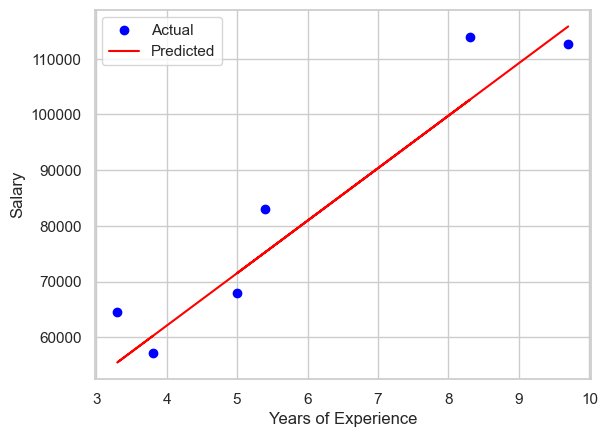

In [33]:
plt.scatter(X_test, y_test, color='blue',label='Actual')
plt.plot(X_test, y_pred, color='red',label='Predicted')
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.legend()
plt.show()

In [34]:
#Predict salary for someone with 5 years of experience 
model.predict([[5]])

C:\Users\saptu\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([71499.27809463])

## Residual = actual − predicted

>Positive → underprediction,
>Negative → overprediction

In [35]:
residuals= y_test - y_pred
residuals

27    -3155.210113
15    -3560.278095
23    11215.131339
17     7820.195776
8      8967.207955
9     -3000.699707
Name: Salary, dtype: float64

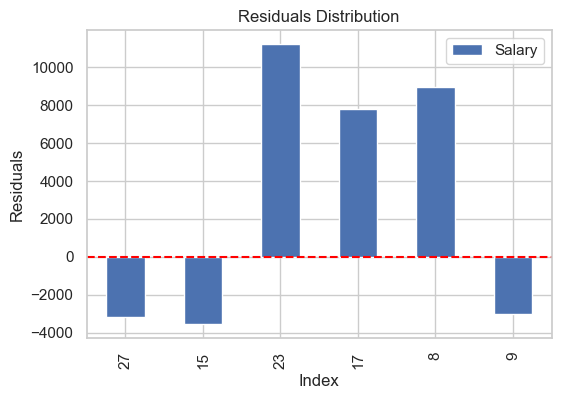

In [37]:
residuals.plot(kind='bar', figsize=(6,4))
plt.title("Residuals Distribution")
plt.xlabel("Index")
plt.ylabel("Residuals")
plt.legend()
plt.axhline(0, color='red',linestyle='--')
plt.show()